# FusionDB reactor browser

Lists all reactors side by side (one column per reactor) with every available field, including derived values. Columns with warnings are highlighted in yellow; mismatches beyond the 1% tolerance are highlighted in red (red overrides yellow). Warning messages are echoed below the table.


In [1]:
from pathlib import Path
import time
import warnings
import cProfile
import pstats
import sys

def find_repo_root(start: Path) -> Path:
    """Return repository root containing reactors and source package."""
    for candidate in (start, *start.parents):
        if (candidate / "reactors").is_dir() and (candidate / "src" / "fusdb").is_dir():
            return candidate
    return start

root = find_repo_root(Path.cwd())
src_path = str(root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import pandas as pd
from IPython.display import display

from fusdb import Reactor
from fusdb.plotting.tables import build_reactor_comparison_table


/home/alessmor/Scrivania/fusdb/src/fusdb/relation_class.py:476: RuntimeWarning: Could not convert relation 'Bremsstrahlung radiation' to sympy expression for target 'P_brem'. direct=ValueError: Cannot integrate bremsstrahlung profile over volume.; proxy=ValueError: Cannot integrate bremsstrahlung profile over volume.
  expr, symbols = _build_symbolic_model(


In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

PROFILE_TOP = 25
LOG_STAGE_TIMES = True

profiler = cProfile.Profile()
profiler.enable()

warnings.filterwarnings("ignore", message="Unknown solver tag 'verbosity'.*")

reactors = {}
table_result = None

metadata_fields = ["id", "name", "organization", "country", "tags", "solve_status", "year", "doi", "notes"]

def log(msg: str) -> None:
    """Print one notebook progress line."""
    print(msg)

log(f"Loading reactors from {root.resolve()}")

reactor_dirs = []
reactors_path = root / "reactors"
if reactors_path.is_dir():
    for item in reactors_path.iterdir():
        if item.is_dir() and (item / "reactor.yaml").exists():
            reactor_dirs.append((item, item / "reactor.yaml"))

for reactor_dir, yaml_path in reactor_dirs:
    log(f"Loading {reactor_dir.name} from {yaml_path.name}...")
    t0 = time.perf_counter()
    try:
        reactor = Reactor.from_yaml(yaml_path)
        t_loaded = time.perf_counter()
        try:
            reactor.solve()
        except Exception as exc:
            log(f"  ERROR solving reactor: {exc}")
        t_solved = time.perf_counter()
    except Exception as exc:
        log(f"  ERROR loading reactor: {exc}")
        import traceback
        traceback.print_exc()
        continue

    reactor_id = reactor.id or reactor_dir.name
    reactors[reactor_id] = reactor

    elapsed = time.perf_counter() - t0
    log(f"  Loaded reactor in {elapsed:.2f}s")
    if LOG_STAGE_TIMES:
        log(f"  - parse/load: {t_loaded - t0:.2f}s")
        log(f"  - solve: {t_solved - t_loaded:.2f}s")

# Build one shared multi-reactor table payload from the plotting helper.
t_table = time.perf_counter()
table_result = build_reactor_comparison_table(
    reactors,
    metadata_fields=metadata_fields,
    include_diagnostics=True,
)
if LOG_STAGE_TIMES:
    log(f"  - table build: {time.perf_counter() - t_table:.2f}s")

profiler.disable()
pstats.Stats(profiler).sort_stats("cumtime").print_stats(PROFILE_TOP)


Loading reactors from /home/alessmor/Scrivania/fusdb
Loading HAMMIR from reactor.yaml...
  Loaded reactor in 2.00s
  - parse/load: 0.04s
  - solve: 1.96s
Loading STEP_2024 from reactor.yaml...


Inconsistency: relation 'Normalized beta' computed beta_N = 3.92, but input specifies beta_N = 0.0393


  Loaded reactor in 28.83s
  - parse/load: 2.23s
  - solve: 26.59s
Loading DEMO_2022 from reactor.yaml...


Inconsistency: relation 'L-H transition threshold power' computed P_LH = 1.74e+08, but input specifies P_LH = 1.21e+08
Inconsistency: relation 'Total fusion power' computed P_fus = 2.25e+09, but input specifies P_fus = 2e+09


  Loaded reactor in 28.05s
  - parse/load: 3.77s
  - solve: 24.28s
Loading INFINITY_TWO from reactor.yaml...
  Loaded reactor in 1.55s
  - parse/load: 0.78s
  - solve: 0.77s
Loading STELLARIS from reactor.yaml...


Inconsistency: relation 'Total fusion power' computed P_fus = 5.27e+09, but input specifies P_fus = 2.7e+09


  Loaded reactor in 5.27s
  - parse/load: 0.67s
  - solve: 4.61s
Loading ARC_2015 from reactor.yaml...


Inconsistency: relation 'Normalized beta' computed beta_N = 2.53, but input specifies beta_N = 2.59
Inconsistency: relation 'Total fusion power' computed P_fus = 4.4e+08, but input specifies P_fus = 5.25e+08


  Loaded reactor in 73.77s
  - parse/load: 0.61s
  - solve: 73.16s
  - table build: 3.50s
         108003373 function calls (105911835 primitive calls) in 142.575 seconds

   Ordered by: cumulative time
   List reduced from 7248 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       14    0.000    0.000  142.959   10.211 /home/alessmor/Scrivania/fusdb/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
  4024/14    0.141    0.000  142.959   10.211 {built-in method builtins.exec}
        6    0.000    0.000  131.351   21.892 /home/alessmor/Scrivania/fusdb/src/fusdb/reactor_class.py:212(solve)
        6    0.002    0.000  130.392   21.732 /home/alessmor/Scrivania/fusdb/src/fusdb/relationsystem_class.py:2556(solve)
       11    0.024    0.002  125.560   11.415 /home/alessmor/Scrivania/fusdb/src/fusdb/relationsystem_class.py:2140(_run_closure_phase)
       27    0.006    0.000  109.226    4.045 /home/ales

In [3]:
# Display diagnostics-aware comparison table
if table_result is None:
    raise RuntimeError("table_result is missing; run previous cell first.")

display(table_result["styled"])

for rid, msgs in table_result["warnings"].items():
    if not msgs:
        continue
    print(f"Warnings for {rid}:")
    for msg in msgs:
        print(f" - {msg}")


,Hammir2024,STEP2024EBCC,DEMO_2022,InfinityTwo2025,Stellaris2025,ARC_2015
id,Hammir2024,STEP2024EBCC,DEMO_2022,InfinityTwo2025,Stellaris2025,ARC_2015
name,Hammir 2024,STEP 2024 EB-CC,EU-DEMO 2022,INFINITY TWO 2025,Stellaris 2025 - Point A,ARC 2015
organization,Realta,UKAEA,EUROFUSION,TypeOne Energy,Proxima,MIT
country,,United Kingdom,EUU,,,United States
tags,mirror,"tokamak, sphericaltokamak, hmode, step","tokamak, demo, hmode",stellarator,stellarator,"tokamak, compact, imode"
solve_status,final_check_undecidable; final_check=30 undecidable,"cycle_detected; final_check=4 violated, 17 undecidable",final_check_undecidable; final_check=15 undecidable,final_check_undecidable; final_check=54 undecidable,"cycle_detected; final_check=2 violated, 16 undecidable","cycle_detected; final_check=2 violated, 17 undecidable"
year,2024,2024,2022,2025,2025,2015
doi,10.1088/1741-4326/ad3fcb,10.1088/1741-4326/ad6ea2,10.1016/j.fusengdes.2022.113080,10.1017/S0022377825000364,10.1016/j.fusengdes.2025.114868,10.1016/j.fusengdes.2015.07.008
notes,,Refers to EC+EBW heating scenario with Conservative Confinement conditions,EU-DEMO Physics Baseline 2022,,,Conceptual compact tokamak from MIT
R,,3.6,9.0,12.5,12.74,3.3


In [4]:
# Display reactor info using the new __repr__ method
print("Loaded reactors:")
for rid, reactor in sorted(reactors.items()):
    print(f"  {reactor}")


Loaded reactors:
  Reactor(id='ARC_2015', name='ARC 2015', org='MIT', year=2015, 105 variables, 96 relations)
  Reactor(id='DEMO_2022', name='EU-DEMO 2022', org='EUROFUSION', year=2022, 98 variables, 100 relations)
  Reactor(id='Hammir2024', name='Hammir 2024', org='Realta', year=2024, 59 variables, 84 relations)
  Reactor(id='InfinityTwo2025', name='INFINITY TWO 2025', org='TypeOne Energy', year=2025, 41 variables, 86 relations)
  Reactor(id='STEP2024EBCC', name='STEP 2024 EB-CC', org='UKAEA', year=2024, 94 variables, 99 relations)
  Reactor(id='Stellaris2025', name='Stellaris 2025 - Point A', org='Proxima', year=2025, 88 variables, 86 relations)


In [5]:
# Prepare reactors for plotting (use all loaded reactors)
plot_reactors = reactors
log(f"Plotting all reactors: {', '.join(sorted(plot_reactors))}")


Plotting all reactors: ARC_2015, DEMO_2022, Hammir2024, InfinityTwo2025, STEP2024EBCC, Stellaris2025


Skipping Hammir2024: Missing 95% geometry variables for plotting: R, a, kappa_95, delta_95
Skipping InfinityTwo2025: Missing 95% geometry variables for plotting: kappa_95, delta_95
Skipping Stellaris2025: Missing 95% geometry variables for plotting: kappa_95, delta_95


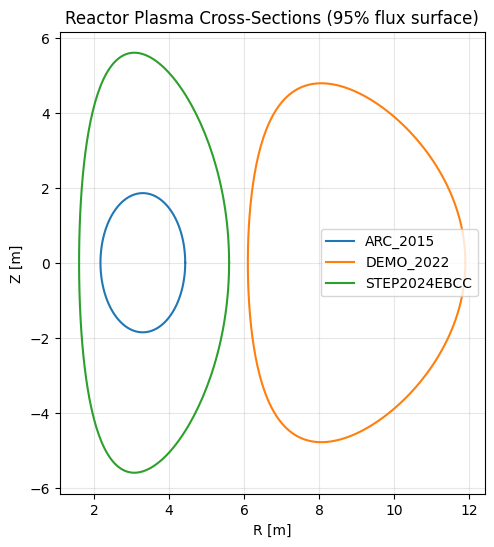

In [6]:
# Plot plasma cross-sections for all loaded reactors
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))
plotted = 0

for name, reactor in sorted(plot_reactors.items()):
    try:
        reactor.plot_cross_sections(ax=ax, label=name)
        plotted += 1
    except Exception as e:
        log(f"Skipping {name}: {e}")

if plotted:
    ax.legend()
    plt.title('Reactor Plasma Cross-Sections (95% flux surface)')
    plt.show()
else:
    log("No reactors had sufficient geometry data to plot.")


## POPCON scan example (DEMO)


Inconsistency: relation 'Greenwald density fraction' computed f_GW = 0.893, but input specifies f_GW = 1.2
Inconsistency: relation 'L-H transition threshold power' computed P_LH = 1.41e+08, but input specifies P_LH = 1.21e+08
Inconsistency: relation 'Total fusion power' computed P_fus = 1.67e+08, but input specifies P_fus = 2e+09


Text(0.5, 1.0, 'DEMO POPCON: P_fus')

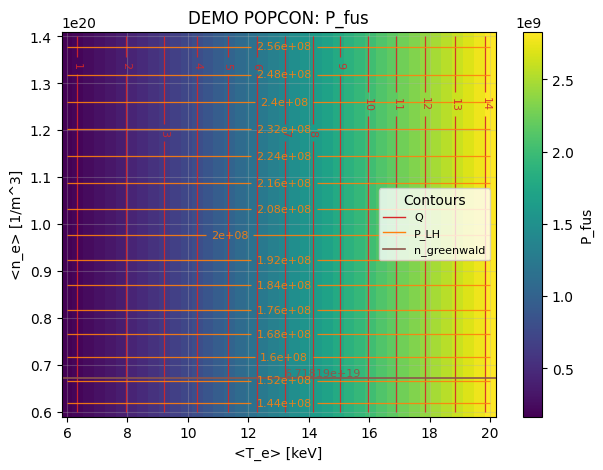

In [7]:
import numpy as np
from fusdb.registry.reactor_defaults import apply_reactor_defaults

# POPCON scan for DEMO over temperature and density.
demo = Reactor.from_yaml(root / "reactors" / "DEMO_2022" / "reactor.yaml")

scan_T = np.linspace(6.0, 20.0, 40)
scan_n = np.linspace(0.6e20, 1.4e20, 40)

# Ensure scan axes exist as explicit scalar inputs.
for name, first_value in (("n_avg", scan_n[0]), ("T_avg", scan_T[0])):
    var = demo.variables_dict.get(name)
    if var is None:
        var = make_variable(name=name, ndim=0, input_source="explicit")
        demo.variables_dict[name] = var
    var.input_value = None
    var.current_value = None
    var.add_value(float(first_value), as_input=True)
    var.input_source = "explicit"

# Clear scalar inputs that should follow averages.
for name in ("n_e", "n_i", "T_e", "T_i"):
    var = demo.variables_dict.get(name)
    if var is None:
        continue
    var.input_value = None
    var.current_value = None
    var.input_source = None

# Refresh defaults and rebuild applicable relations after changing inputs.
new_defaults = apply_reactor_defaults(demo.variables_dict, relations=demo.default_relations)
if new_defaults:
    demo.default_relations.extend(new_defaults)
demo.refresh_relations()
demo.solve()

fill_var = "P_fus"
contour_vars = ["Q_sci", "P_LH", "n_GW"]  # P_aux is fixed in DEMO YAML.
scan_outputs = [fill_var, *contour_vars]
contour_counts = {name: 15 for name in contour_vars}

result = demo.popcon(
    {"T_avg": scan_T, "n_avg": scan_n},
    outputs=scan_outputs,
)

ax = demo.plot_popcon(
    result,
    x="T_avg",
    y="n_avg",
    fill=fill_var,
    contours=contour_vars,
    contour_counts=contour_counts,
    constraint_contours=False,
)
ax.set_xlabel("<T_e> [keV]")
ax.set_ylabel("<n_e> [1/m^3]")
ax.set_title("DEMO POPCON: P_fus")
